In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

In [4]:
df_all.head()

,Close,High,Low,Open,Volume,Return,Target_Return,Target_Class,Ticker,Return_lag1,...,Momentum_5,Momentum_10,MA_5,MA_20,MA_ratio,Volatility_10,Volatility_30,Momentum_vol_adjusted,Price_vs_MA20,RSI
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-03,26.446150,27.368326,26.240724,27.129408,279904000,-0.023578,-0.032083,0,AAPL,-0.008744,...,-0.035269,-0.103203,27.173177,27.874969,0.974824,0.013527,0.014586,-7.629384,0.948742,33.176882
2015-08-04,25.597666,26.280925,25.287296,26.218404,496554400,-0.032083,0.006629,1,AAPL,-0.023578,...,-0.070838,-0.123212,26.782871,27.751603,0.965093,0.015102,0.015439,-8.158675,0.922385,24.518907
2015-08-05,25.767363,26.222869,25.030514,25.220308,397250400,0.006629,0.002176,1,AAPL,-0.032083,...,-0.061712,-0.078422,26.443921,27.671554,0.955636,0.012185,0.015546,-6.435791,0.931186,21.462811
2015-08-06,25.823437,26.130726,25.596897,26.011848,211612000,0.002176,0.003388,1,AAPL,0.006629,...,-0.054906,-0.075973,26.143875,27.622221,0.946480,0.012396,0.015426,-6.128824,0.934879,18.412300
2015-08-07,25.910917,26.074656,25.682134,25.700078,154681600,0.003388,0.036357,1,AAPL,0.002176,...,-0.043340,-0.067928,25.909106,27.541424,0.940732,0.012885,0.015471,-5.271819,0.940798,10.037951


In [5]:
features = [

    "Return",

    "Return_lag1",
    "Return_lag2",
    "Return_lag3",

    "Momentum_5",
    "Momentum_10",

    "MA_ratio",

    "Volatility_10",
    "Volatility_30",

    "RSI",

    "Price_vs_MA20",

    "Momentum_vol_adjusted"

]

In [6]:
target = "Target_Return"

In [7]:
train_size = int(len(df_all) * 0.8)

train_all = df_all.iloc[:train_size]
test_all = df_all.iloc[train_size:]

In [8]:
X_train = train_all[features]
X_test  = test_all[features]

y_train = train_all[target]
y_test  = test_all[target]

In [9]:
X_train.shape, X_test.shape

((10472, 12), (2618, 12))

In [10]:
from sklearn.neighbors import KNeighborsRegressor

In [11]:
model_knn = KNeighborsRegressor(n_neighbors=10)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

In [12]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

mae_knn, rmse_knn

(0.01279639698860038, np.float64(0.017989274586123885))

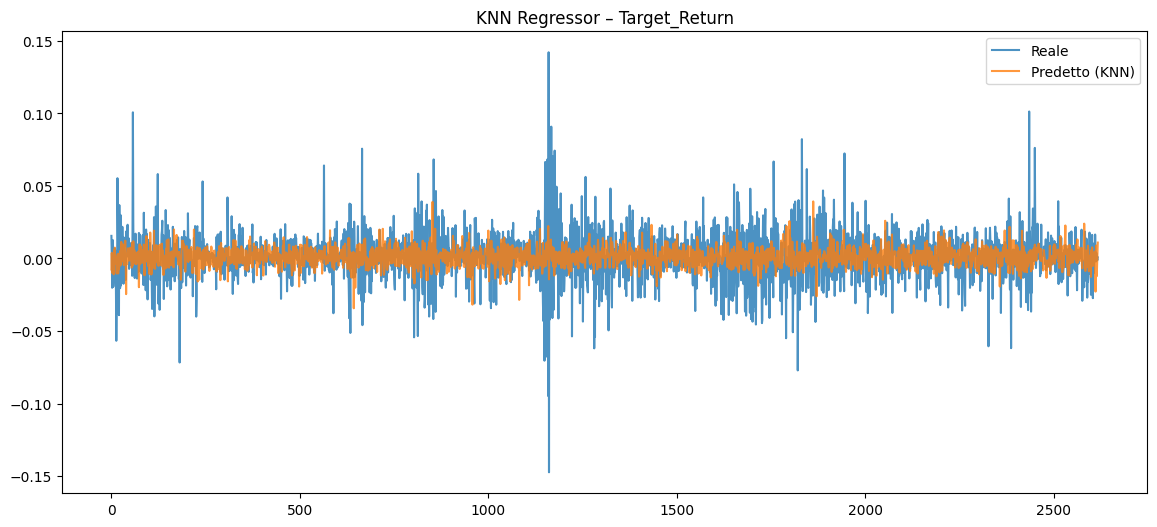

In [13]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Reale", alpha=0.8)
plt.plot(y_pred_knn, label="Predetto (KNN)", alpha=0.8)

plt.title("KNN Regressor – Target_Return")

plt.legend()

plt.show()

In [14]:
strategy_returns = np.sign(y_pred_knn) * y_test.values

equity_curve = (1 + strategy_returns).cumprod()

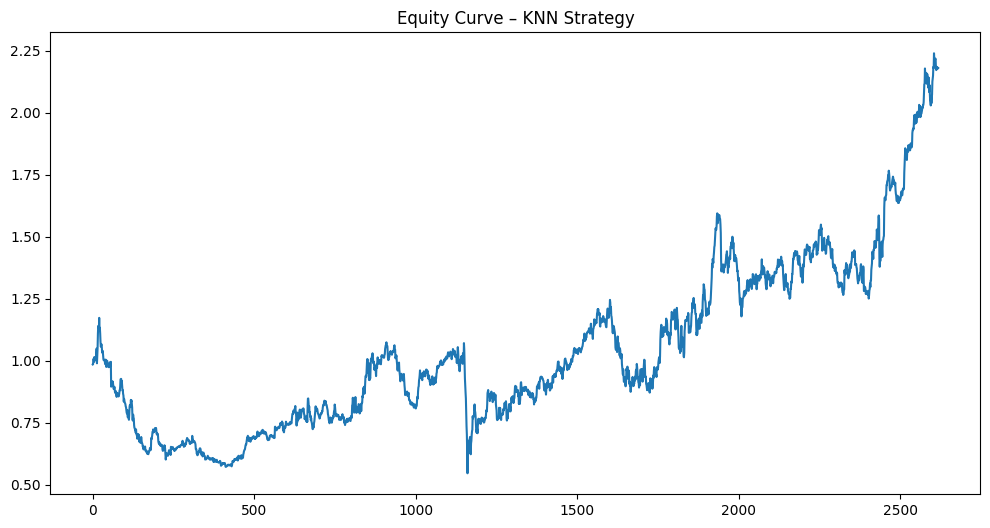

In [15]:
plt.figure(figsize=(12,6))

plt.plot(equity_curve)

plt.title("Equity Curve – KNN Strategy")

plt.show()

In [16]:
from sklearn.tree import DecisionTreeRegressor

In [17]:
model_tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

In [18]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

mae_tree, rmse_tree

(0.011638373658614693, np.float64(0.01679262613805546))

In [19]:
print("KNN")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)

print()

print("Decision Tree")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)

KNN
MAE: 0.01279639698860038
RMSE: 0.017989274586123885

Decision Tree
MAE: 0.011638373658614693
RMSE: 0.01679262613805546


In [21]:
X = df_all[features]
y = df_all["Target_Return"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

MSE: 0.00028478457164742113
R2: 0.006465171660995694


In [25]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

pred_ridge = ridge.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))

MSE: 0.00028478478646350137
R2: 0.006464422226936883


In [26]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)

lasso.fit(X_train_scaled, y_train)

pred_lasso = lasso.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, pred_lasso))
print("R2:", r2_score(y_test, pred_lasso))

MSE: 0.0002866400011168872
R2: -7.910039944603042e-06
